In [1]:


import pandas as pd                        # veri okuma ve işleme
import numpy as np                         # matematiksel işlemler
import matplotlib.pyplot as plt            # grafik çizme
import seaborn as sns                      # daha güzel grafikler
 
from sklearn.model_selection import train_test_split   # veriyi böl
from sklearn.preprocessing import StandardScaler       # veriyi ölçeklendir
from sklearn.linear_model import LogisticRegression    # model 1
from sklearn.ensemble import RandomForestClassifier    # model 2
from sklearn.svm import SVC                            # model 3
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
 
print("Kütüphaneler yüklendi!")

Kütüphaneler yüklendi!


In [10]:
import pandas as pd

df = pd.read_csv(r"C:\Users\tugce\OneDrive\Masaüstü\archive (1)\breast_cancer_enhanced_dataset - Kopya.csv")

print(f"\n Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print("\nİlk 5 satır:")
print(df.head())


 Veri seti boyutu: 5500 satır, 17 sütun

İlk 5 satır:
             id diagnosis  radius_mean  texture_mean  perimeter_mean  \
0  5.683796e+06         B    11.829858     21.726166       75.154378   
1 -6.253379e+06         B    10.991150     17.103260       71.798929   
2  4.213892e+06         M    21.433519     15.092437      142.753006   
3 -2.986069e+06         B    11.700452     14.872127       74.154481   
4  6.469594e+05         B    13.259377     17.212990       83.621014   

     area_mean  smoothness_mean  compactness_mean  concavity_mean  \
0   435.022394         0.087089          0.050717        0.015868   
1   381.386295         0.089339          0.109498        0.097344   
2  1392.399890         0.099557          0.152079        0.193372   
3   404.112556         0.101291          0.077563        0.043749   
4   521.124238         0.072905          0.043312        0.046983   

   concave points_mean  shape_irregularity  border_complexity  \
0             0.011641          

In [13]:
print("\n Sütun bilgileri:")
print(df.info())
 
print("\n İstatistiksel özet:")
print(df.describe())
 
print("\n Eksik veri kontrolü:")
print(df.isnull().sum())
 
print("\n Teşhis dağılımı (B=İyi Huylu, M=Kötü Huylu):")
print(df['diagnosis'].value_counts())
print(f"\nKötü huylu oranı: %{df['diagnosis'].value_counts(normalize=True)['M']*100:.1f}")


 Sütun bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            5500 non-null   float64
 1   diagnosis                     5500 non-null   object 
 2   yarıçap_ortalama              5500 non-null   float64
 3   doku_ortalama                 5500 non-null   float64
 4   perimeter_mean                5500 non-null   float64
 5   area_mean                     5500 non-null   float64
 6   pürüzsüzlük_ortalama          5500 non-null   float64
 7   compactness_mean              5500 non-null   float64
 8   concavity_mean                5500 non-null   float64
 9   concave points_mean           5500 non-null   float64
 10  shape_irregularity            5500 non-null   float64
 11  border_complexity             5500 non-null   float64
 12  tumor_aggressiveness          5500 non-null

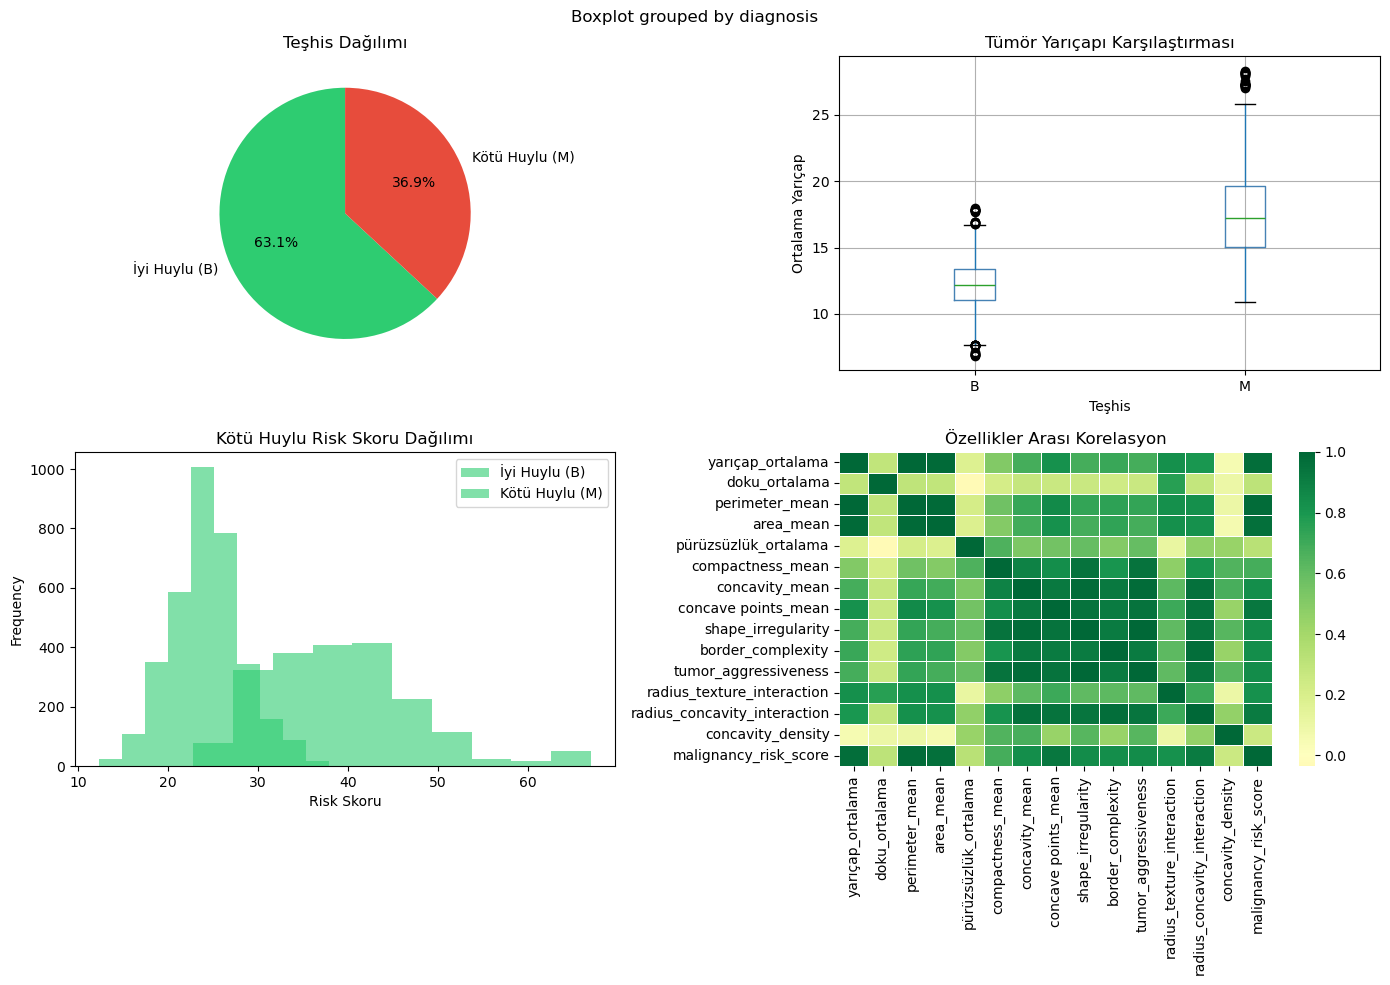


 Grafik kaydedildi: 1_keşifci_analiz.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Meme Kanseri Veri Seti - Keşifçi Analiz", fontsize=16, fontweight='bold')

# Grafik 1: Teşhis dağılımı
counts = df['diagnosis'].value_counts()

axes[0, 0].pie(
    counts,
    labels=['İyi Huylu (B)', 'Kötü Huylu (M)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0, 0].set_title("Teşhis Dağılımı")

# Grafik 2: Tümör yarıçapı
df.boxplot(
    column='yarıçap_ortalama',
    by='diagnosis',
    ax=axes[0, 1],
    boxprops=dict(color='steelblue')
)

axes[0, 1].set_title("Tümör Yarıçapı (İyi Huylu vs Kötü Huylu)")
axes[0, 1].set_xlabel("Teşhis")
axes[0, 1].set_ylabel("Ortalama Yarıçap")

plt.sca(axes[0, 1])
plt.title("Tümör Yarıçapı Karşılaştırması")

# Grafik 3: Kötü huylu risk skoru dağılımı
df.groupby('diagnosis')['malignancy_risk_score'].plot(
    kind='hist', alpha=0.6, ax=axes[1, 0],
    color=['#2ecc71', '#e74c3c'], legend=True
)
axes[1, 0].set_title("Kötü Huylu Risk Skoru Dağılımı")
axes[1, 0].set_xlabel("Risk Skoru")
axes[1, 0].legend(['İyi Huylu (B)', 'Kötü Huylu (M)'])
 
# Grafik 4: Özellikler arası korelasyon ısı haritası
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['id'])
corr = numeric_cols.corr()
sns.heatmap(corr, ax=axes[1, 1], cmap='RdYlGn', center=0,
            annot=False, linewidths=0.5)
axes[1, 1].set_title("Özellikler Arası Korelasyon")
 
plt.tight_layout()
plt.savefig("1_keşifci_analiz.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Grafik kaydedildi: 1_keşifci_analiz.png")
 

In [19]:
# ── ADIM 5: VERİYİ HAZIRLA ───────────────────────────────────
# Modele vereceğimiz özellikleri (X) ve tahmin edeceğimiz hedefi (y) ayırıyoruz.
 
# Hedef sütun: diagnosis (B veya M)
# Önce bunu sayıya çeviriyoruz: M=1 (kötü huylu), B=0 (iyi huylu)
df['target'] = (df['diagnosis'] == 'M').astype(int)
 
# Özellikler: id ve diagnosis dışındaki tüm sütunlar
X = df.drop(columns=['id', 'diagnosis', 'target'])
y = df['target']
 
print(f"\n Özellik sayısı: {X.shape[1]}")
print(f" Hedef: {y.value_counts().to_dict()} (0=İyi Huylu, 1=Kötü Huylu)")
 
# Veriyi eğitim (%80) ve test (%20) olarak ayır
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y → eğitim ve test setinde B/M oranının aynı kalmasını sağlar
 
print(f"\n Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti: {X_test.shape[0]} örnek")


 Özellik sayısı: 15
 Hedef: {0: 3470, 1: 2030} (0=İyi Huylu, 1=Kötü Huylu)

 Eğitim seti: 4400 örnek
Test seti: 1100 örnek


In [20]:
# Ölçeklendirme: özelliklerin birimlerini eşitleriz (örn: yarıçap vs alan)
# Modeller büyük sayılardan etkilenebilir, bunu engeller
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
print("\n Veri hazırlandı!")


 Veri hazırlandı!


In [21]:

 
# ── ADIM 6: MODELLERİ EĞİT VE KARŞILAŞTIR ───────────────────
# 3 farklı model deneyeceğiz, hangisi daha iyi sonuç veriyor göreceğiz.
 
modeller = {
    "Lojistik Regresyon": LogisticRegression(max_iter=1000, random_state=42),
    "Rastgele Orman":     RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":                SVC(kernel='rbf', random_state=42)
}
 
sonuclar = {}
 
print("\n" + "="*55)
print("MODEL KARŞILAŞTIRMASI")
print("="*55)
 
for model_adi, model in modeller.items():
    # Modeli eğit
    model.fit(X_train_scaled, y_train)
 
    # Test verisiyle tahmin yap
    y_pred = model.predict(X_test_scaled)
 
    # Metrikleri hesapla
    acc    = accuracy_score(y_test, y_pred)
    rapor  = classification_report(y_test, y_pred, output_dict=True)
    recall = rapor['1']['recall']   # Kötü huyluları yakalama oranı (ÇOK ÖNEMLİ!)
    f1     = rapor['1']['f1-score']
 
    sonuclar[model_adi] = {
        'Doğruluk (Accuracy)': acc,
        'Recall (Kötü Huylu)': recall,
        'F1 Skoru': f1
    }
 
    print(f"\n {model_adi}")
    print(f"   Doğruluk  : %{acc*100:.2f}")
    print(f"   Recall    : %{recall*100:.2f}  ← Kötü huyluları kaçırmama oranı")
    print(f"   F1 Skoru  : %{f1*100:.2f}")


MODEL KARŞILAŞTIRMASI

 Lojistik Regresyon
   Doğruluk  : %93.18
   Recall    : %89.16  ← Kötü huyluları kaçırmama oranı
   F1 Skoru  : %90.61

 Rastgele Orman
   Doğruluk  : %99.36
   Recall    : %98.77  ← Kötü huyluları kaçırmama oranı
   F1 Skoru  : %99.13

 SVM
   Doğruluk  : %97.00
   Recall    : %93.35  ← Kötü huyluları kaçırmama oranı
   F1 Skoru  : %95.83


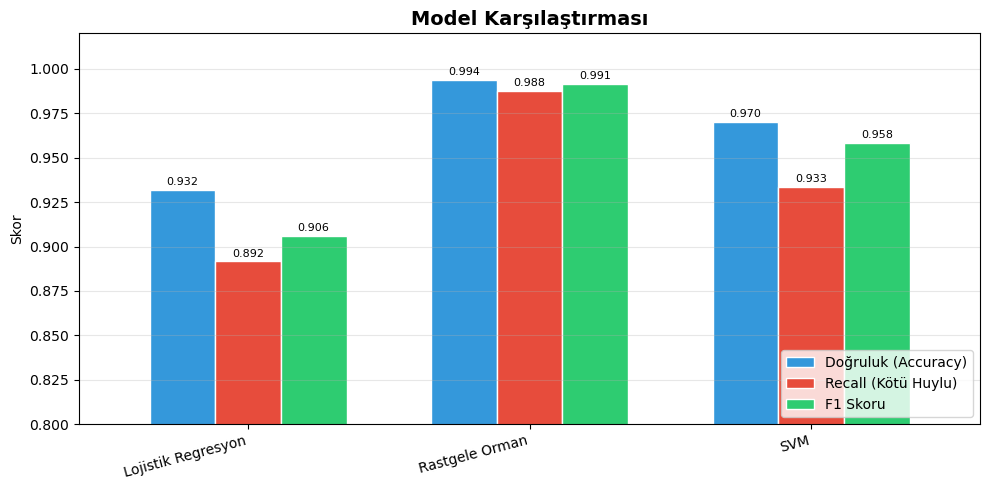


 Grafik kaydedildi: 2_model_karsilastirma.png


In [22]:
sonuc_df = pd.DataFrame(sonuclar).T
 
fig, ax = plt.subplots(figsize=(10, 5))
sonuc_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'],
              edgecolor='white', width=0.7)
ax.set_title("Model Karşılaştırması", fontsize=14, fontweight='bold')
ax.set_ylabel("Skor")
ax.set_ylim(0.8, 1.02)
ax.set_xticklabels(sonuc_df.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
 
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
 
plt.tight_layout()
plt.savefig("2_model_karsilastirma.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Grafik kaydedildi: 2_model_karsilastirma.png")

In [23]:
# ── ADIM 8: EN İYİ MODELİN DETAYLI ANALİZİ ──────────────────
# Confusion Matrix: modelin hangi hataları yaptığını gösterir
# Sağlık verisinde en kritik hata: kötü huyluyu "iyi huylu" sanmak!
 
print("\n" + "="*55)
print("DETAYLI ANALİZ: Rastgele Orman")
print("="*55)
 
rf_model = modeller["Rastgele Orman"]
y_pred_rf = rf_model.predict(X_test_scaled)
 
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred_rf,
      target_names=['İyi Huylu (B)', 'Kötü Huylu (M)']))
 


DETAYLI ANALİZ: Rastgele Orman

Sınıflandırma Raporu:
                precision    recall  f1-score   support

 İyi Huylu (B)       0.99      1.00      0.99       694
Kötü Huylu (M)       1.00      0.99      0.99       406

      accuracy                           0.99      1100
     macro avg       0.99      0.99      0.99      1100
  weighted avg       0.99      0.99      0.99      1100



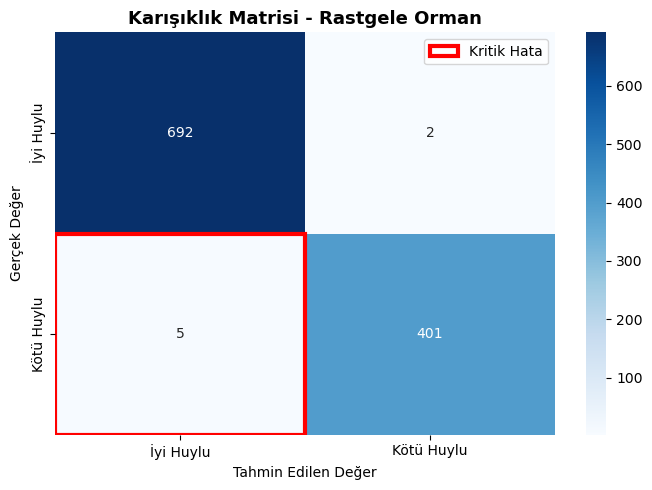


 Grafik kaydedildi: 3_confusion_matrix.png


In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['İyi Huylu', 'Kötü Huylu'],
            yticklabels=['İyi Huylu', 'Kötü Huylu'])
ax.set_title("Karışıklık Matrisi - Rastgele Orman", fontsize=13, fontweight='bold')
ax.set_ylabel("Gerçek Değer")
ax.set_xlabel("Tahmin Edilen Değer")
 
# En kritik hücreyi vurgula (sol-alt = kötü huylu ama iyi huylu tahmin edilmiş)
ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
             edgecolor='red', lw=3, label='Kritik Hata'))
ax.legend(loc='upper right')
 
plt.tight_layout()
plt.savefig("3_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Grafik kaydedildi: 3_confusion_matrix.png")

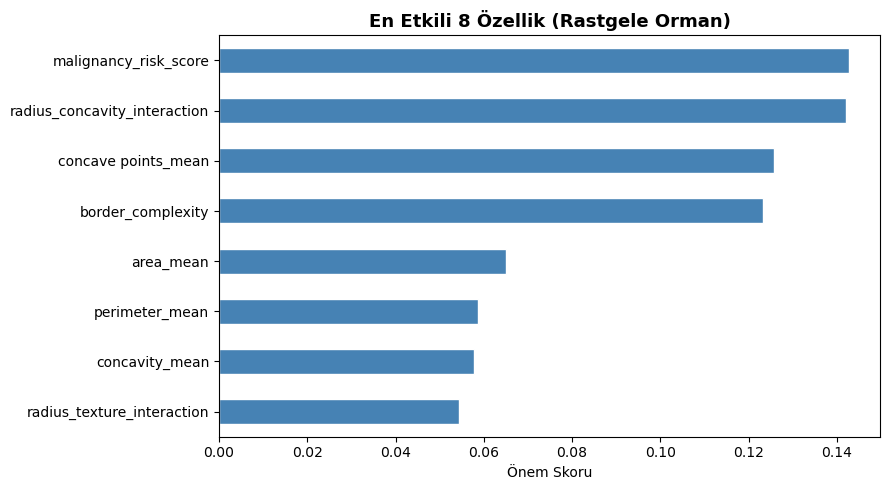

 Grafik kaydedildi: 4_ozellik_onemliligi.png


In [27]:

feature_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(8)
 
fig, ax = plt.subplots(figsize=(9, 5))
feature_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("En Etkili 8 Özellik (Rastgele Orman)", fontsize=13, fontweight='bold')
ax.set_xlabel("Önem Skoru")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("4_ozellik_onemliligi.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Grafik kaydedildi: 4_ozellik_onemliligi.png")
 